In [1]:
# This is a comment - Python ignores it
print("Hello Data Science World!")

# Variables - like boxes that store stuff
my_name = "Harsh Hariya"
my_age = 29
print(f"I'm {my_name} and I'm {my_age} years old")

Hello Data Science World!
I'm Harsh Hariya and I'm 29 years old


In [2]:
# A list of salaries in thousands
salaries = [30, 45, 50, 38, 60, 55, 42]

# Basic operations
print(f"Number of people: {len(salaries)}")
print(f"Highest salary: {max(salaries)}k")
print(f"Lowest salary: {min(salaries)}k")
print(f"Average salary: {sum(salaries)/len(salaries)}k")

Number of people: 7
Highest salary: 60k
Lowest salary: 30k
Average salary: 45.714285714285715k


In [3]:
# Import pandas (Excel on steroids)
import pandas as pd

# Create a simple dataset
data = {
    'Name': ['Rahul', 'Priya', 'Amit', 'Sneha', 'Vikram'],
    'Age': [25, 28, 22, 30, 27],
    'City': ['Mumbai', 'Delhi', 'Bangalore', 'Mumbai', 'Pune'],
    'Salary': [50000, 65000, 48000, 70000, 55000]
}

# Convert to DataFrame (fancy table)
df = pd.DataFrame(data)

# Display it
print(df)

     Name  Age       City  Salary
0   Rahul   25     Mumbai   50000
1   Priya   28      Delhi   65000
2    Amit   22  Bangalore   48000
3   Sneha   30     Mumbai   70000
4  Vikram   27       Pune   55000


In [4]:
# Quick stats
print("=== DATASET OVERVIEW ===")
print(df.info())
print("\n=== STATISTICS ===")
print(df.describe())

# Answer questions
print("\n=== INSIGHTS ===")
print(f"Average salary: ₹{df['Salary'].mean()}")
print(f"Highest paid person: {df.loc[df['Salary'].idxmax(), 'Name']}")
print(f"People in Mumbai: {df[df['City'] == 'Mumbai'].shape[0]}")

=== DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      int64 
 2   City    5 non-null      object
 3   Salary  5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes
None

=== STATISTICS ===
            Age        Salary
count   5.00000      5.000000
mean   26.40000  57600.000000
std     3.04959   9555.103348
min    22.00000  48000.000000
25%    25.00000  50000.000000
50%    27.00000  55000.000000
75%    28.00000  65000.000000
max    30.00000  70000.000000

=== INSIGHTS ===
Average salary: ₹57600.0
Highest paid person: Sneha
People in Mumbai: 2


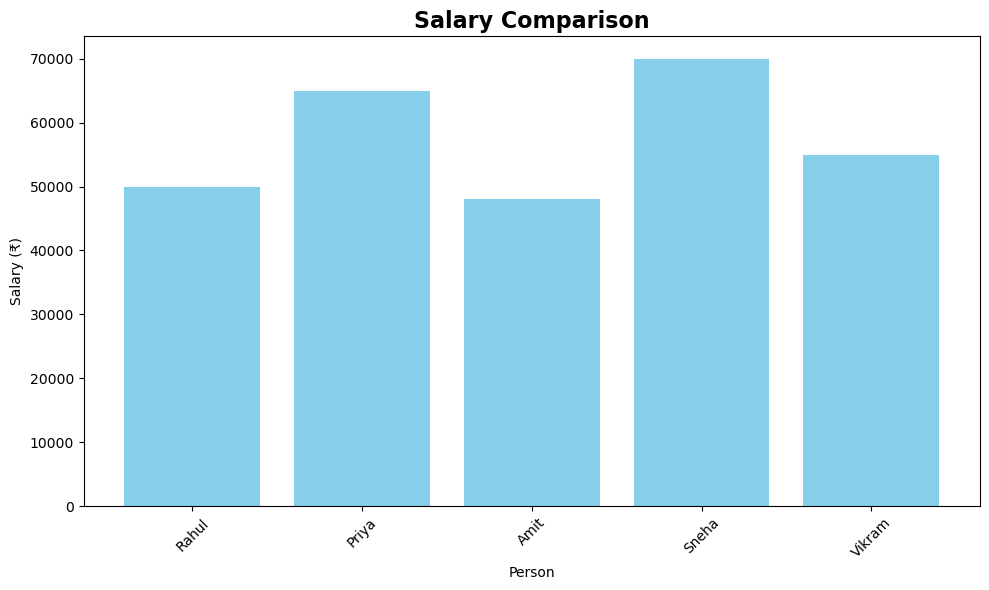

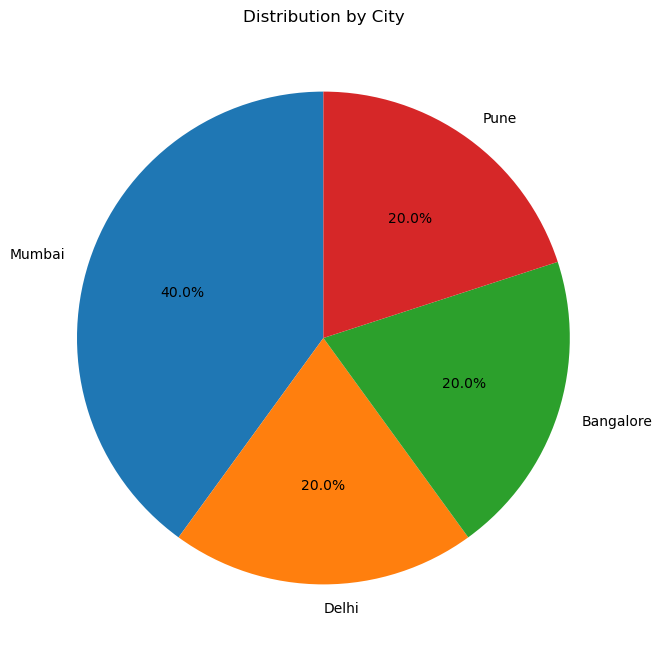

In [5]:
import matplotlib.pyplot as plt

# Bar chart of salaries
plt.figure(figsize=(10, 6))
plt.bar(df['Name'], df['Salary'], color='skyblue')
plt.title('Salary Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Person')
plt.ylabel('Salary (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart of cities
city_counts = df['City'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution by City')
plt.show()

In [6]:
# We'll use a real salary dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Load it
df = pd.read_csv(url)

# See first few rows
print(df.head())
print(f"\nDataset has {len(df)} rows and {len(df.columns)} columns")

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

In [7]:
# What columns do we have?
print(df.columns)

# Any missing data?
print("\nMissing values:")
print(df.isnull().sum())

# Basic stats
print("\nStatistics:")
print(df.describe())

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.0000

In [8]:
# Question 1: What was the survival rate?
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Question 2: Did gender matter?
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("\nSurvival rate by gender:")
print(gender_survival)

# Question 3: Did ticket class matter?
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\nSurvival rate by class:")
print(class_survival)

# Question 4: What was the average age?
avg_age = df['Age'].mean()
print(f"\nAverage age of passengers: {avg_age:.1f} years")

Overall survival rate: 38.4%

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average age of passengers: 29.7 years


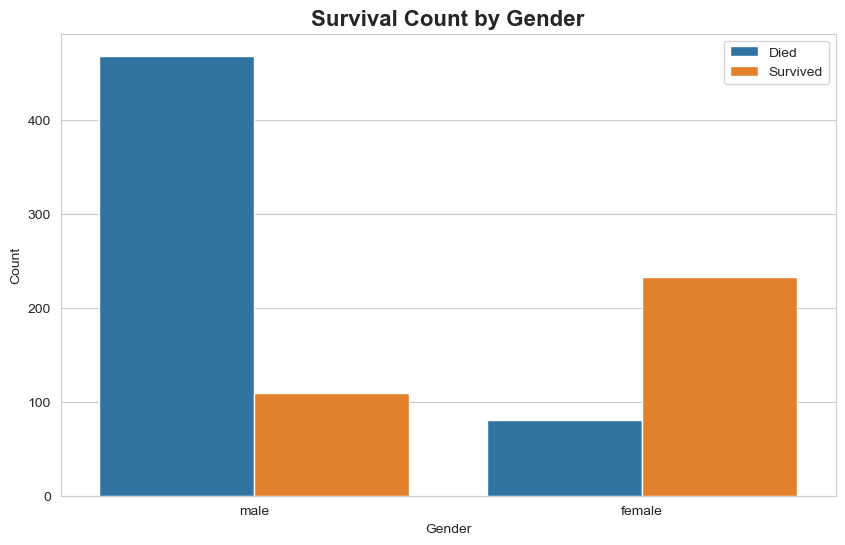

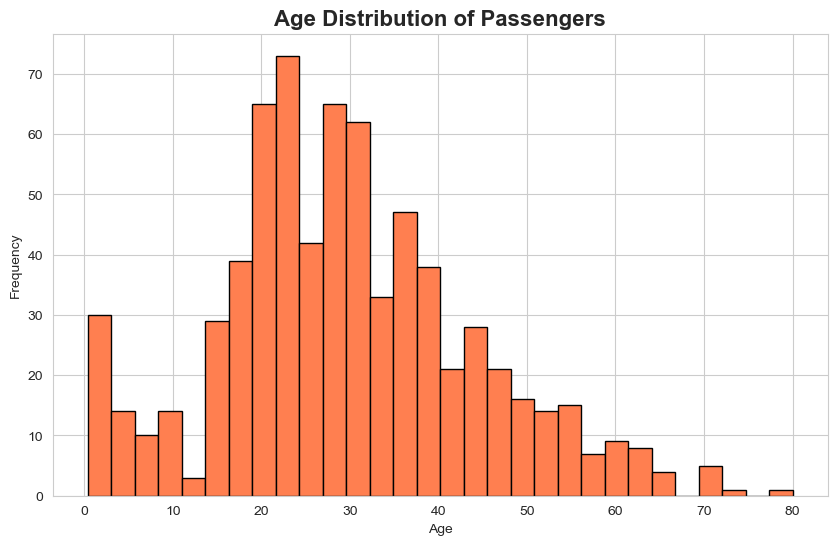

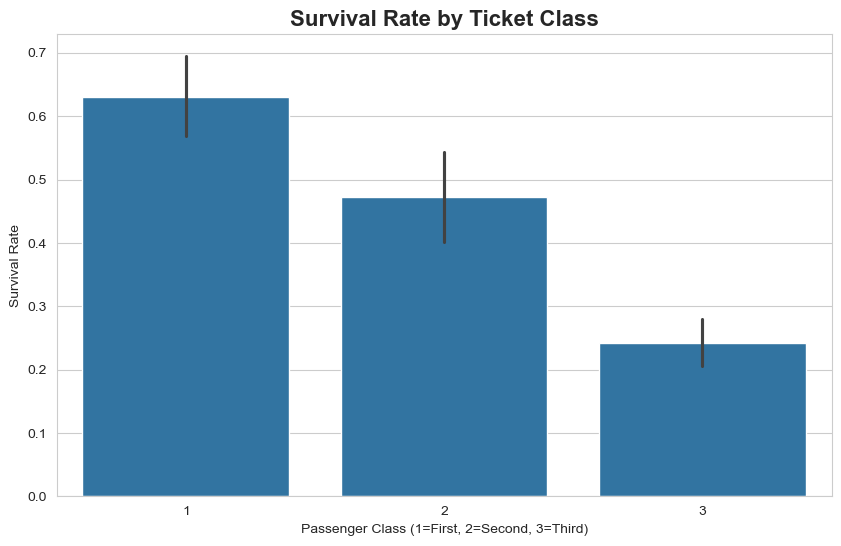

In [9]:
import seaborn as sns

# Set style
sns.set_style('whitegrid')

# 1. Survival by Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival Count by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])
plt.show()

# 2. Age distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=30, color='coral', edgecolor='black')
plt.title('Age Distribution of Passengers', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 3. Survival by Class
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Ticket Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate')
plt.show()

# Titanic Dataset Analysis - Key Findings

## Dataset Overview
- Total passengers: 891
- Survival rate: 38.4%

## Key Insights

### 1. Gender Analysis
- Women had 74.2% survival rate
- Men had 18.9 survival rate
- **Conclusion:** WOmen were saved first, and then Men

### 2. Class Analysis
- First class: 62% survival
- Second class: 47.2% survival  
- Third class: 24.2% survival
- **Conclusion:** FIrst class passenger had good survival rate 

### 3. Age Pattern
- Average age: 29.7 years
- Age group was 20-40, where highest age frequency was 22-24 age group

## What I Learned
[Age group of 20-40 were most saved with female more in it and most of them were first class passenger in it]

In [10]:
young= df['Age'].min()
young

0.42

In [11]:
old=df['Age'].max()
old

80.0

In [12]:
ticket=df['Fare'].max()
ticket

512.3292

In [13]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Define 'Alone' (FamilySize == 1) vs 'With Family' (FamilySize > 1)
df['TravelMethod'] = 'Alone'
df.loc[df['FamilySize'] > 1, 'TravelMethod'] = 'With Family'

# Count the occurrences
travel_counts = df['TravelMethod'].value_counts()
print(travel_counts)

# Percentage breakdown
print("\nPercentage Breakdown:")
print(df['TravelMethod'].value_counts(normalize=True) * 100)

TravelMethod
Alone          537
With Family    354
Name: count, dtype: int64

Percentage Breakdown:
TravelMethod
Alone          60.26936
With Family    39.73064
Name: proportion, dtype: float64


In [16]:
# STEP 1: Filter the data into two groups
# Group 1: People who survived (Survived = 1)
survivors = df[df['Survived'] == 1]

# Group 2: People who died (Survived = 0)  
non_survivors = df[df['Survived'] == 0]

# Let's see how many in each group
print(f"Number of survivors: {len(survivors)}")
print(f"Number of non-survivors: {len(non_survivors)}")

Number of survivors: 342
Number of non-survivors: 549


In [25]:
#step 2: 
#getting Survivor and non survivors average age and comparison
survivors_age= survivors['Age'].dropna().mean()
non_survivors_age= non_survivors['Age'].dropna().mean()
print(f"Surviors average age: {survivors_age:.1f}")
print(f"Non Surviors average age: {non_survivors_age:.1f}")

#calculating the difference and comparing 
age_diff= survivors_age-non_survivors_age
print(f"The age difference is: {age_diff:.1f}")

if age_diff > 0:
    print("Survivors were Older")
else:
    print("Survivors were younger")

Surviors average age: 28.3
Non Surviors average age: 30.6
The age difference is: -2.3
Survivors were younger


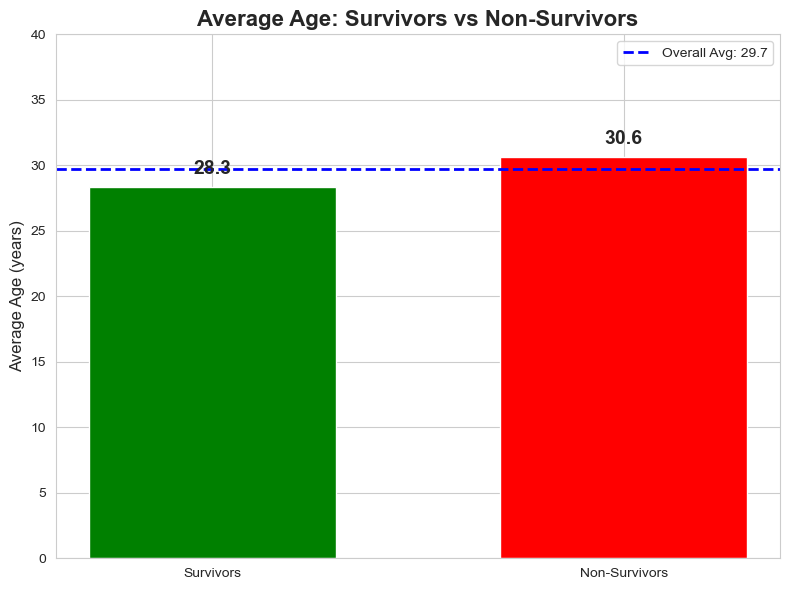

In [27]:
# STEP 3: Create a simple bar chart comparing average ages

import matplotlib.pyplot as plt

# Data for our chart
groups = ['Survivors', 'Non-Survivors']
ages = [survivors_age, non_survivors_age]

# Create the chart
plt.figure(figsize=(8, 6))
plt.bar(groups, ages, color=['green', 'red'], width=0.6)

# Add a horizontal line showing the overall average
overall_avg = df['Age'].dropna().mean()
plt.axhline(y=overall_avg, color='blue', linestyle='--', linewidth=2, label=f'Overall Avg: {overall_avg:.1f}')

# Labels and title
plt.title('Average Age: Survivors vs Non-Survivors', fontsize=16, fontweight='bold')
plt.ylabel('Average Age (years)', fontsize=12)
plt.ylim(0, 40)  # Y-axis from 0 to 40

# Add the exact numbers on top of bars
for i, (group, age) in enumerate(zip(groups, ages)):
    plt.text(i, age + 1, f'{age:.1f}', ha='center', fontsize=14, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [28]:
#step 4: Create age categories

def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Child (0-17)'
    elif age <60:
        return 'Adult (18-59)'
    else:
        return 'Senior (60+)'

df['AgeGroup']=df['Age'].apply(categorize_age)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,TravelMethod,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,With Family,Adult (18-59)
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,With Family,Adult (18-59)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,Adult (18-59)
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,With Family,Adult (18-59)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Alone,Adult (18-59)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Alone,Adult (18-59)
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Alone,Adult (18-59)
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,With Family,Unknown
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Alone,Adult (18-59)


In [38]:
# STEP 5: Calculate survival rate for each age group

# Group by AgeGroup and calculate survival rate
age_group_survival= df.groupby('AgeGroup')['Survived'].mean()*100
print(age_group_survival)
print("----------")

age_group_counts=df['AgeGroup'].value_counts()
print(age_group_counts)

AgeGroup
Adult (18-59)    38.608696
Child (0-17)     53.982301
Senior (60+)     26.923077
Unknown          29.378531
Name: Survived, dtype: float64
----------
AgeGroup
Adult (18-59)    575
Unknown          177
Child (0-17)     113
Senior (60+)      26
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18116\637617569.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_known_age, x='AgeGroup', y='Survived',


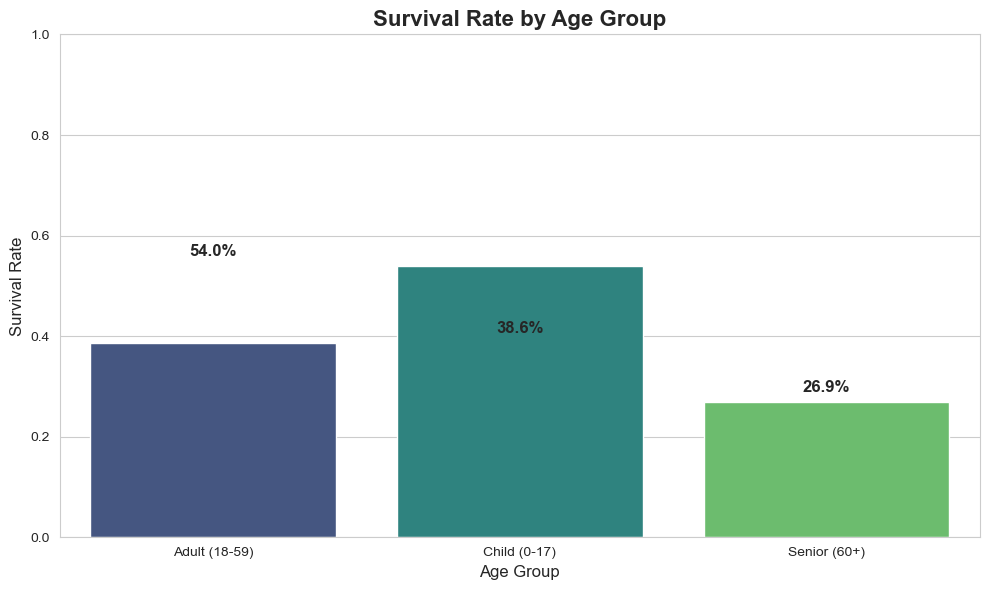

In [40]:
# STEP 6: Visualize survival by age group

import seaborn as sns

# Filter out Unknown ages for cleaner chart
df_known_age = df[df['AgeGroup'] != 'Unknown']

# Create the chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_known_age, x='AgeGroup', y='Survived', 
            palette='viridis', errorbar=None)

# Customize
plt.title('Survival Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.ylim(0, 1)  # 0 to 1 (since Survived is 0 or 1)

# Add percentage labels on bars
age_groups_order = ['Child (0-17)', 'Adult (18-59)', 'Senior (60+)']
for i, group in enumerate(age_groups_order):
    if group in df_known_age['AgeGroup'].values:
        rate = df_known_age[df_known_age['AgeGroup'] == group]['Survived'].mean()
        plt.text(i, rate + 0.02, f'{rate*100:.1f}%', 
                ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Age Analysis - Key Findings

### Average Age Comparison
- Survivors average age: 28.3 years
- Non-survivors average age: 30.6 years
- **Insight:** Survivors were younger

### Survival by Age Group
- Children (0-17): 38.6% survival rate
- Adults (18-59): 54% survival rate  
- Seniors (60+): 26.9% survival rate

### My Conclusion
[Write 2-3 sentences: What does this tell you about the Titanic disaster?
nothing]

[Why do you think children had different survival rate than adults?
Since children and females were saved first, survival rates is more for children]

[What does this say about human behavior in crisis?
Crisis says that children, the female and rich were saved first]

### What Surprised Me
[Male survival rates were less, also the 3rd class passenger survival rate is low]